In [8]:
import numpy as np


X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [9]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0  # Bias / Intercept
        self.theta_1 = 0.0  # Slope / Weight
        self.sse_history = []

    def fit(self, X, y):
        n_samples = len(X)

        for _ in range(self.n_iters):
         
            y_predicted = self.theta_0 + self.theta_1 * X

           
            errors = y_predicted - y

            
            sse = np.sum(errors**2)
            self.sse_history.append(sse)

            
            d_theta_0 = (1 / n_samples) * np.sum(errors)
            d_theta_1 = (1 / n_samples) * np.sum(errors * X)

            
            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X



model = LinearRegressionGD(learning_rate=0.001, n_iters=100)

model.fit(X, y)


print(f"Theta 0 (Intercept): {model.theta_0:.4f}")
print(f"Theta 1 (Slope): {model.theta_1:.4f}")

Theta 0 (Intercept): -800078057397833370411578621208836291643524324127290033176576.0000
Theta 1 (Slope): -58290953186123026625062564784147052867034031815437873840128000.0000


In [10]:

predicted_price = model.predict(70)
print(f"Predicted price for 70 m^2: {predicted_price:.2f} thousand")

Predicted price for 70 m^2: -4081166801086009983466359462644703674302648372209740195630678016.00 thousand


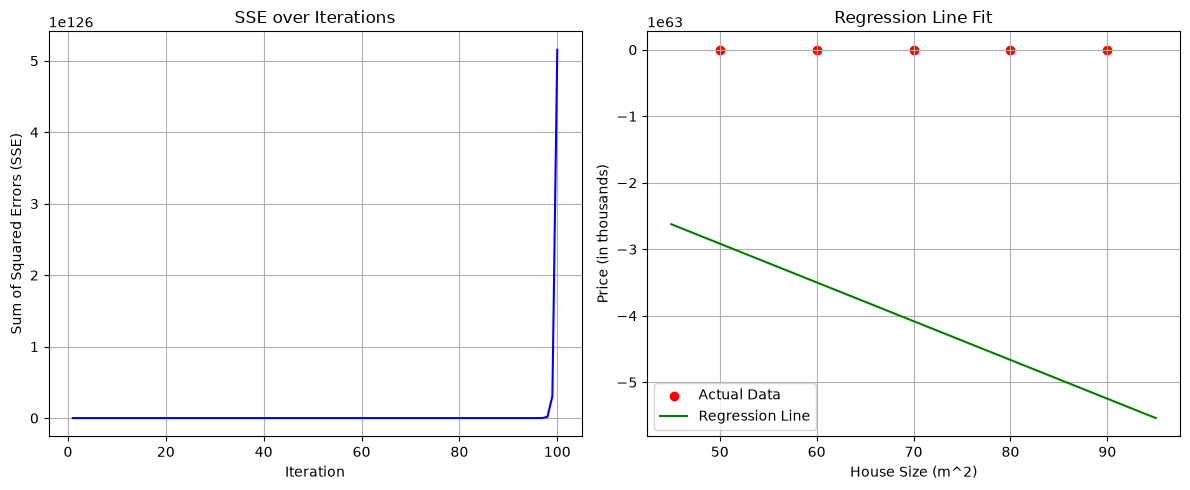

In [11]:
import matplotlib.pyplot as plt


def plot_training(model, X, y):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


    ax1.plot(range(1, model.n_iters + 1), model.sse_history, color="blue")
    ax1.set_title("SSE over Iterations")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Sum of Squared Errors (SSE)")
    ax1.grid(True)

    
    ax2.scatter(X, y, color="red", label="Actual Data")
    x_range = np.linspace(min(X) - 5, max(X) + 5, 100)
    y_range = model.predict(x_range)
    ax2.plot(x_range, y_range, color="green", label="Regression Line")
    ax2.set_title("Regression Line Fit")
    ax2.set_xlabel("House Size (m^2)")
    ax2.set_ylabel("Price (in thousands)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



plot_training(model, X, y)

In [12]:
def calculate_mse(self, X, y):
    y_pred = self.predict(X)
    return np.mean((y - y_pred) ** 2)


# يتم إضافتها داخل الكلاس واستدعاؤها كالتالي:
# mse_val = model.calculate_mse(X, y)

In [13]:

X_mean = np.mean(X)
X_std = np.std(X)

X_scaled = (X - X_mean) / X_std


model_scaled = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_scaled.fit(X_scaled, y)

In [14]:
class MultiLinearRegressionGD:

    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            errors = y_pred - y

            dw = (1 / n_samples) * np.dot(X.T, errors)
            db = (1 / n_samples) * np.sum(errors)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias